# InMemoryStore — LangGraph

Long-term memory used FROM INSIDE a LangGraph node, not as standalone
script calls. The graph is compiled with `store=InMemoryStore()`, and
`memory_node` receives that store via an injected `store` keyword-only
parameter — LangGraph passes it in automatically at run time.

One node dispatches on `state["action"]` to cover all four `BaseStore`
operations:

- **namespace** — `(user_id, "memories")`, scoping memories per user.
- **create / edit** — `put(namespace, key, value)`.
- **search** — `search(namespace)`.
- **delete** — `delete(namespace, key)`.


In [8]:
from typing import Any, Optional, TypedDict

from langgraph.graph import END, START, StateGraph
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

In [9]:
class MemoryState(TypedDict):
    user_id: str
    action: str  # "create" | "search" | "edit" | "delete"
    key: str
    text: Optional[str]
    result: Any

In [10]:
def memory_node(state: MemoryState, *, store: BaseStore) -> MemoryState:
    namespace = (state["user_id"], "memories")

    if state["action"] == "create":
        store.put(namespace, state["key"], {"text": state["text"]})
        return {"result": f"created {state['key']}"}

    if state["action"] == "search":
        items = store.search(namespace)
        return {"result": [(item.key, item.value) for item in items]}

    if state["action"] == "edit":
        # put() with the SAME key overwrites the existing memory
        store.put(namespace, state["key"], {"text": state["text"]})
        return {"result": f"updated {state['key']}"}

    if state["action"] == "delete":
        store.delete(namespace, state["key"])
        return {"result": f"deleted {state['key']}"}

    raise ValueError(f"unknown action: {state['action']}")

In [11]:
graph = StateGraph(MemoryState)

graph.add_node("memory_node", memory_node)

graph.add_edge(START, "memory_node")
graph.add_edge("memory_node", END)

store = InMemoryStore()

# store is passed at compile time — this is what makes the injected
# `store` parameter in memory_node work
workflow = graph.compile(store=store)

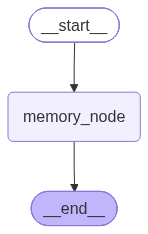

In [12]:
# print/visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

## Create — two memories


In [ ]:
USER = "user_1"

print(
    workflow.invoke(
        {
            "user_id": USER,
            "action": "create",
            "key": "pref-1",
            "text": "Prefers Hindi translations over any other language.",
        }
    )["result"]
)

print(
    workflow.invoke(
        {
            "user_id": USER,
            "action": "create",
            "key": "fact-1",
            "text": "Works as a backend developer.",
        }
    )["result"]
)

created pref-1
created fact-1


## Search


In [14]:
result = workflow.invoke({"user_id": USER, "action": "search", "key": "", "text": None})

for key, value in result["result"]:
    print(key, "->", value)

pref-1 -> {'text': 'Prefers Hindi translations over any other language.'}
fact-1 -> {'text': 'Works as a backend developer.'}


## Edit

Same key (`pref-1`), new text — overwrites the existing memory.


In [ ]:
print(
    workflow.invoke(
        {
            "user_id": USER,
            "action": "edit",
            "key": "pref-1",
            "text": "Strongly prefers Hindi translations; dislikes literal translations.",
        }
    )["result"]
)

result = workflow.invoke({"user_id": USER, "action": "search", "key": "", "text": None})
for key, value in result["result"]:
    print(key, "->", value)

updated pref-1
pref-1 -> {'text': 'Strongly prefers Hindi translations; dislikes literal translations.'}
fact-1 -> {'text': 'Works as a backend developer.'}


## Delete


In [ ]:
print(
    workflow.invoke(
        {"user_id": USER, "action": "delete", "key": "pref-1", "text": None}
    )["result"]
)

result = workflow.invoke({"user_id": USER, "action": "search", "key": "", "text": None})
for key, value in result["result"]:
    print(key, "->", value)

deleted pref-1
fact-1 -> {'text': 'Works as a backend developer.'}
